In [46]:
# ============================================
# Notebook 2: OpenCV Basics
# Goal:
# Learn how to load, inspect, and display images using OpenCV.
# ============================================

# --- Imports ---
import numpy as np          # numerical arrays
import matplotlib.pyplot as plt  # display images
import cv2                 # computer vision library

In [69]:
# ============================================
# Capture an image from your camera
# Goal:
# Take one picture using the default camera and display it.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
WARMUP_FRAMES = 20
SAVE_PATH = "../images/captured_image.png"
DISPLAY_TITLE = "Captured image"

# --- Camera capture ---
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    for _ in range(WARMUP_FRAMES):
        ret, frame = cap.read()

    cap.release()

    if not ret:
        print("Failed to capture image.")
    else:
        cv2.imwrite(SAVE_PATH, frame)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.imshow(rgb)
        plt.title(DISPLAY_TITLE)
        plt.axis("off")
        plt.show()

OpenCV loads images in BGR format (not RGB).
shape (H, W, C): (746, 744, 3)
dtype: uint8


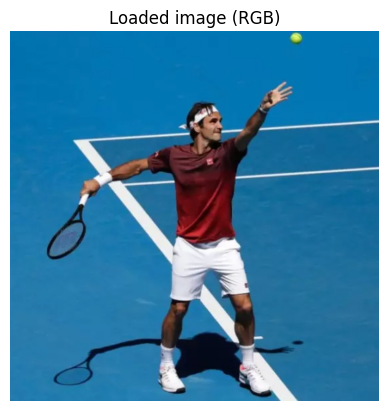

In [70]:
# ============================================
# Load a real image
# Goal:
# Understand how a color image is stored as a 3D array (H, W, C) (Height, Width, Channels).
# ============================================

# --- Parameters ---
IMAGE_PATH = "../images/captured_image.png"
DISPLAY_TITLE = "Loaded image (RGB)"

# --- Load image ---
bgr = cv2.imread(IMAGE_PATH)

if bgr is None:
    raise FileNotFoundError(f"Couldn't load {IMAGE_PATH}. Make sure the file exists.")

print("OpenCV loads images in BGR format (not RGB).")
print("shape (H, W, C):", bgr.shape)
print("dtype:", bgr.dtype)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()


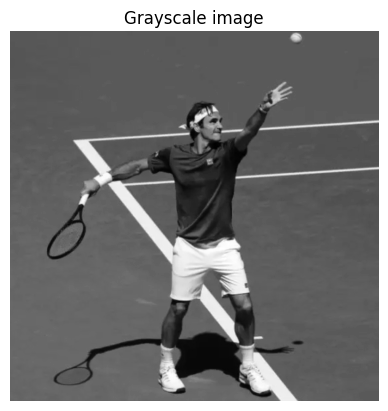

In [71]:
# ============================================
# Convert the image to grayscale
# Goal:
# See the difference between a color image and a 1-channel image.
# ============================================

# --- Parameters ---
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Grayscale image"

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()

Image loaded successfully.


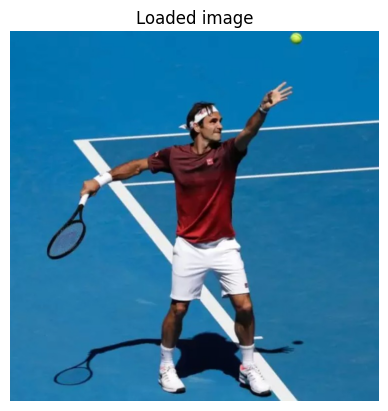

In [72]:
# ============================================
# 🧪 Example: Load and display an image (OpenCV)
# Goal:
# Learn how to load an image and display it correctly
# ============================================

# Load image from disk (OpenCV loads in BGR format)
# img = cv2.imread("../pictures/captured_image.png")
img = cv2.imread("../images/captured_image.png")


# --- Check if loading worked ---
if img is None:
    print("Image not found.")
else:
    print("Image loaded successfully.")

    # ============================================
    # 🔁 Convert BGR → RGB
    # Matplotlib expects RGB, not BGR
    # ============================================
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ============================================
    # 🖼️ Display the image
    # ============================================
    plt.imshow(rgb)
    plt.title("Loaded image")
    plt.axis("off")  # cleaner display (no axes)
    plt.show()


# ============================================
# 🧠 Checkpoint:
# - Why do we convert BGR to RGB?
# - What happens if we skip this step?
# - What does cv2.imread return if the path is wrong?
# ============================================

shape: (746, 744)
dtype: uint8


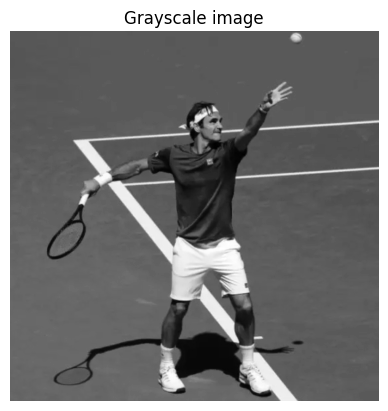

In [73]:
# ============================================
# 🧪 Example: Convert an image to grayscale
# Goal:
# Understand how to reduce a color image to 1 channel
# ============================================

# Convert BGR image → Grayscale
# (collapses 3 color channels into a single intensity value)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Inspect the result ---
print("shape:", gray.shape)   # (height, width) → no channel dimension
print("dtype:", gray.dtype)

# ============================================
# 🖼️ Display the grayscale image
# ============================================
plt.imshow(gray, cmap="gray")  # tell matplotlib it's grayscale
plt.title("Grayscale image")
plt.axis("off")
plt.show()


# ============================================
# 🧠 Checkpoint:
# - What happened to the 3 color channels?
# - Why is the shape now (H, W) instead of (H, W, 3)?
# - What does each pixel value represent now?
# ============================================

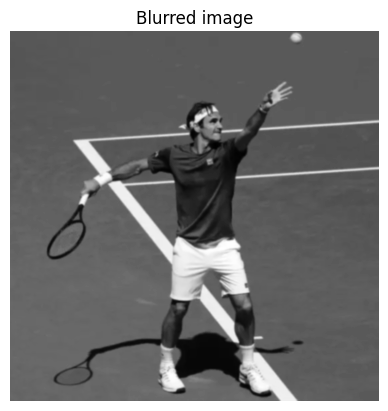

In [74]:
# ============================================
# 🧪 Example: Blur an image (noise reduction)
# Goal:
# Smooth the image before edge detection
# ============================================

# Apply Gaussian blur to reduce noise
# (5, 5) = kernel size, 0 = automatic sigma
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# ============================================
# 🖼️ Display blurred image
# ============================================
plt.imshow(blur, cmap="gray")
plt.title("Blurred image")
plt.axis("off")
plt.show()


# ============================================
# 🧠 Checkpoint:
# - Why do we blur before detecting edges?
# - What might happen if we skip this step?
# ============================================

shape: (746, 744)
dtype: uint8
unique values: [  0 255]


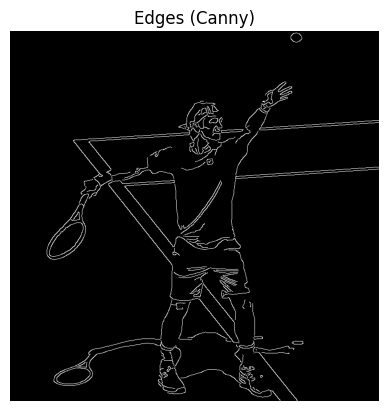

In [75]:
# ============================================
# 🧪 Example: Detect edges with Canny
# Goal:
# Identify strong intensity changes (object boundaries)
# ============================================

# Apply Canny edge detection
# 50 = lower threshold, 150 = upper threshold
edges = cv2.Canny(blur, 50, 150)

# --- Inspect the result ---
print("shape:", edges.shape)   # (height, width)
print("dtype:", edges.dtype)
print("unique values:", np.unique(edges))  # typically [0, 255]

# ============================================
# 🖼️ Display detected edges
# ============================================
plt.imshow(edges, cmap="gray")
plt.title("Edges (Canny)")
plt.axis("off")
plt.show()


# ============================================
# 🧠 Checkpoint:
# - What do the white pixels represent?
# - Why are there only two values (0 and 255)?
# - How might changing thresholds (50, 150) affect the result?
# ============================================

In [76]:
# ============================================
# ✍️ Your turn: Canny edge detection
# Goal:
# Apply edge detection only for the strongest edges
# ============================================

# Apply Canny edge detection
# Try different thresholds (e.g. 30, 100 or 100, 200)
edges = cv2.Canny(blur, ???, ???)

# --- Inspect the result ---
print("shape:", edges.shape)
print("dtype:", edges.dtype)
print("unique values:", np.unique(edges))

# ============================================
# 🖼️ Display detected edges
# ============================================
plt.imshow(edges, cmap="gray")
plt.title("Edges (your version)")
plt.axis("off")
plt.show()


# ============================================
# 🧠 Checkpoint:
# - What input image should you use here?
# - What happens when thresholds are too low?
# - What happens when they are too high?
# ============================================

SyntaxError: invalid syntax (3328879530.py, line 9)

shape: (746, 744)
dtype: uint8
unique values: [  0 255]


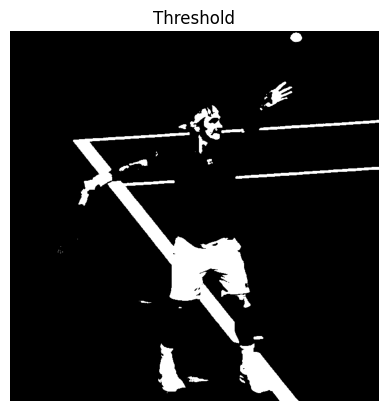

In [77]:
# ============================================
# 🧪 Example: Binary thresholding
# Goal:
# Convert a grayscale image into black & white
# ============================================

# Apply thresholding
# Pixels > 120 → 255 (white)
# Pixels ≤ 120 → 0 (black)
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# --- Inspect the result ---
print("shape:", thresh.shape)
print("dtype:", thresh.dtype)
print("unique values:", np.unique(thresh))  # should be [0, 255]

# ============================================
# 🖼️ Display thresholded image
# ============================================
plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")
plt.show()


# ============================================
# 🧠 Checkpoint:
# - What does the value 120 control?
# - What happens if you increase or decrease it?
# - In what situations would thresholding be useful?
# ============================================

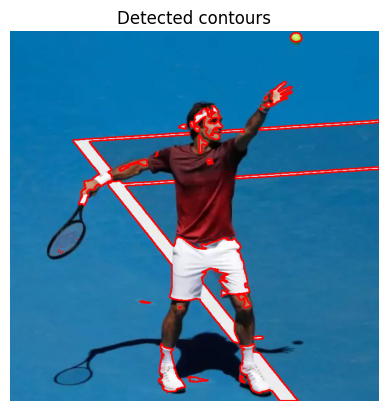

Contours found: 46


In [78]:
# ============================================
# 🧪 Example: Find and draw contours
# Goal:
# Detect object boundaries from a binary image
# ============================================

# Find contours in the thresholded image
# RETR_EXTERNAL → only outer contours
# CHAIN_APPROX_SIMPLE → compress contour points
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a copy of the original image to draw on
canvas = rgb.copy()

# Draw all contours
# -1 → draw all contours
# (255, 0, 0) → red color (in RGB)
# 2 → thickness
cv2.drawContours(canvas, contours, -1, (255, 0, 0), 2)

# ============================================
# 🖼️ Display result
# ============================================
plt.imshow(canvas)
plt.title("Detected contours")
plt.axis("off")
plt.show()

# --- Inspect ---
print("Contours found:", len(contours))


# ============================================
# 🧠 Checkpoint:
# - What does a contour represent?
# - Why do we use a binary image (thresh) here?
# - What would change if we used RETR_TREE instead?
# ============================================

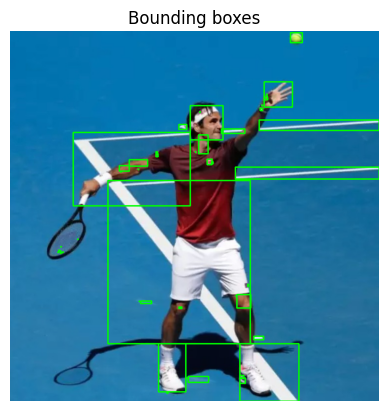

In [79]:
# ============================================
# 🧪 Example: Draw bounding boxes
# Goal:
# Enclose each detected object with a rectangle
# ============================================

# Create a copy of the original image
canvas = rgb.copy()

# Loop over each contour
for c in contours:
    # Compute bounding rectangle (x, y, width, height)
    x, y, w, h = cv2.boundingRect(c)
    
    # Draw rectangle on the image
    # (x, y) → top-left corner
    # (x+w, y+h) → bottom-right corner
    # (0, 255, 0) → green color
    # 2 → thickness
    cv2.rectangle(canvas, (x, y), (x + w, y + h), (0, 255, 0), 2)

# ============================================
# 🖼️ Display result
# ============================================
plt.imshow(canvas)
plt.title("Bounding boxes")
plt.axis("off")
plt.show()


# ============================================
# 🧠 Checkpoint:
# - What does each box represent?
# - How is a bounding box different from a contour?
# - When would bounding boxes be preferred over contours?
# ============================================